STEP 1 — Import Library

In [1]:
# ==================================
# KOZY DATA EXPLORATION
# ==================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")


pd.set_option(
    "display.max_columns",
    None
)

STEP 2 — Load Dataset

In [2]:
df = pd.read_csv(
    "../data/processed/kozy_dataset_final.csv"
)


df.head()

,nama_kost,lokasi,latitude,longitude,harga,jenis,rating,jumlah_ulasan,jumlah_dilihat,sisa_kamar,jumlah_fasilitas,ac,wifi,kmandi_dalam,lemari,meja_belajar,kasur,tv,pmotor,pmobil,sumber
0,Kost Tiara Sidosermo Tipe B,Wonocolo,NaN,NaN,1125000,Putri,NaN,NaN,500.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Mamikos
1,Kost Griya Ayu Baratajaya Tipe A,Gubeng,NaN,NaN,1525000,Putri,NaN,NaN,346.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Mamikos
2,Kost Tiara Sidosermo Tipe A,Wonocolo,NaN,NaN,1400000,Putri,NaN,NaN,500.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Mamikos
3,Kost Matra Ngagel Pucang Sewu,Gubeng,NaN,NaN,2515000,Campur,4.8,NaN,500.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Mamikos
4,Kost Griya Ayu Baratajaya Tipe B,Gubeng,NaN,NaN,1225000,Putri,NaN,NaN,500.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Mamikos


STEP 3 — Melihat Ukuran Dataset

In [3]:
print("Jumlah Baris :", df.shape[0])
print("Jumlah Kolom :", df.shape[1])

Jumlah Baris : 311
Jumlah Kolom : 21


STEP 4 — Melihat Struktur Dataset

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 311 entries, 0 to 310
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   nama_kost         311 non-null    object 
 1   lokasi            311 non-null    object 
 2   latitude          71 non-null     float64
 3   longitude         71 non-null     float64
 4   harga             311 non-null    int64  
 5   jenis             311 non-null    object 
 6   rating            29 non-null     float64
 7   jumlah_ulasan     71 non-null     float64
 8   jumlah_dilihat    247 non-null    float64
 9   sisa_kamar        171 non-null    float64
 10  jumlah_fasilitas  71 non-null     float64
 11  ac                71 non-null     float64
 12  wifi              71 non-null     float64
 13  kmandi_dalam      71 non-null     float64
 14  lemari            71 non-null     float64
 15  meja_belajar      71 non-null     float64
 16  kasur             71 non-null     float64
 1

STEP 5 — Melihat Semua Nama Fitur

In [5]:
for i,col in enumerate(df.columns):
    print(i+1, col)

1 nama_kost
2 lokasi
3 latitude
4 longitude
5 harga
6 jenis
7 rating
8 jumlah_ulasan
9 jumlah_dilihat
10 sisa_kamar
11 jumlah_fasilitas
12 ac
13 wifi
14 kmandi_dalam
15 lemari
16 meja_belajar
17 kasur
18 tv
19 pmotor
20 pmobil
21 sumber


STEP 6 — Identifikasi Jenis Variabel

In [6]:
numerik = df.select_dtypes(
    include=['int64','float64']
).columns


kategori = df.select_dtypes(
    include=['object']
).columns



print("FITUR NUMERIK")
print(numerik)


print("\nFITUR KATEGORI")
print(kategori)

FITUR NUMERIK
Index(['latitude', 'longitude', 'harga', 'rating', 'jumlah_ulasan',
       'jumlah_dilihat', 'sisa_kamar', 'jumlah_fasilitas', 'ac', 'wifi',
       'kmandi_dalam', 'lemari', 'meja_belajar', 'kasur', 'tv', 'pmotor',
       'pmobil'],
      dtype='object')

FITUR KATEGORI
Index(['nama_kost', 'lokasi', 'jenis', 'sumber'], dtype='object')


STEP 7 — Menentukan Skala Pengukuran Variabel

In [7]:
skala = pd.DataFrame({

"Fitur":[
"harga",
"rating",
"jumlah_dilihat",
"jumlah_fasilitas",
"jenis",
"lokasi",
"ac",
"wifi"
],

"Skala":[
"Rasio",
"Interval",
"Rasio",
"Rasio",
"Nominal",
"Nominal",
"Nominal/Biner",
"Nominal/Biner"
]

})


skala

,Fitur,Skala
0,harga,Rasio
1,rating,Interval
2,jumlah_dilihat,Rasio
3,jumlah_fasilitas,Rasio
4,jenis,Nominal
5,lokasi,Nominal
6,ac,Nominal/Biner
7,wifi,Nominal/Biner


STEP 8 — Cek Missing Value

In [8]:
missing = pd.DataFrame({

"Jumlah Missing":
df.isnull().sum(),

"Persentase":
(df.isnull().sum()/len(df))*100

})


missing.sort_values(
"Jumlah Missing",
ascending=False
)

,Jumlah Missing,Persentase
rating,282,90.675241
jumlah_fasilitas,240,77.170418
kasur,240,77.170418
latitude,240,77.170418
longitude,240,77.170418
pmobil,240,77.170418
pmotor,240,77.170418
jumlah_ulasan,240,77.170418
tv,240,77.170418
ac,240,77.170418


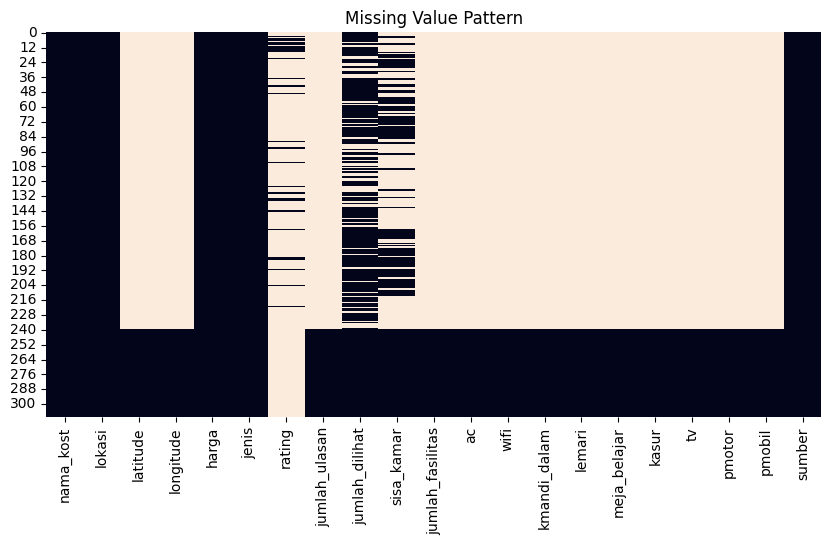

In [9]:
plt.figure(figsize=(10,5))

sns.heatmap(
    df.isnull(),
    cbar=False
)

plt.title(
    "Missing Value Pattern"
)

plt.show()

STEP 9 — Cek Data Duplicate

In [10]:
duplicate = df.duplicated().sum()

print(
"Jumlah duplicate:",
duplicate
)

Jumlah duplicate: 0


In [11]:
df[df.duplicated()]

,nama_kost,lokasi,latitude,longitude,harga,jenis,rating,jumlah_ulasan,jumlah_dilihat,sisa_kamar,jumlah_fasilitas,ac,wifi,kmandi_dalam,lemari,meja_belajar,kasur,tv,pmotor,pmobil,sumber


In [12]:
df[
df.duplicated(
subset=["nama_kost"],
keep=False
)
]

,nama_kost,lokasi,latitude,longitude,harga,jenis,rating,jumlah_ulasan,jumlah_dilihat,sisa_kamar,jumlah_fasilitas,ac,wifi,kmandi_dalam,lemari,meja_belajar,kasur,tv,pmotor,pmobil,sumber


STEP 10 — Statistik Deskriptif Numerik

In [13]:
df.describe()

,latitude,longitude,harga,rating,jumlah_ulasan,jumlah_dilihat,sisa_kamar,jumlah_fasilitas,ac,wifi,kmandi_dalam,lemari,meja_belajar,kasur,tv,pmotor,pmobil
count,71.000000,71.000000,3.110000e+02,29.000000,71.0,247.000000,171.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000
mean,-7.305380,112.749421,1.304052e+06,4.837931,0.0,312.651822,2.982456,6.183099,0.619718,0.873239,0.521127,0.901408,0.746479,0.971831,0.169014,0.929577,0.450704
std,0.027329,0.039429,5.970178e+05,0.259689,0.0,544.147906,2.831490,2.009334,0.488911,0.335073,0.503109,0.300235,0.438123,0.166633,0.377432,0.257679,0.501105
min,-7.364197,112.627780,1.250000e+05,4.000000,0.0,3.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-7.327431,112.738579,8.000000e+05,4.800000,0.0,98.000000,1.000000,5.000000,0.000000,1.000000,0.000000,1.000000,0.500000,1.000000,0.000000,1.000000,0.000000
50%,-7.303908,112.761845,1.250000e+06,5.000000,0.0,194.000000,2.000000,6.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000
75%,-7.280962,112.771618,1.652500e+06,5.000000,0.0,356.000000,3.500000,8.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000
max,-7.259570,112.809624,4.000000e+06,5.000000,0.0,6442.000000,10.000000,9.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [14]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
latitude,71.0,-7.305380e+00,0.027329,-7.364197,-7.327431,-7.303908e+00,-7.280962e+00,-7.259570e+00
longitude,71.0,1.127494e+02,0.039429,112.627780,112.738579,1.127618e+02,1.127716e+02,1.128096e+02
harga,311.0,1.304052e+06,597017.768953,125000.000000,800000.000000,1.250000e+06,1.652500e+06,4.000000e+06
rating,29.0,4.837931e+00,0.259689,4.000000,4.800000,5.000000e+00,5.000000e+00,5.000000e+00
jumlah_ulasan,71.0,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00
jumlah_dilihat,247.0,3.126518e+02,544.147906,3.000000,98.000000,1.940000e+02,3.560000e+02,6.442000e+03
sisa_kamar,171.0,2.982456e+00,2.831490,1.000000,1.000000,2.000000e+00,3.500000e+00,1.000000e+01
jumlah_fasilitas,71.0,6.183099e+00,2.009334,1.000000,5.000000,6.000000e+00,8.000000e+00,9.000000e+00
ac,71.0,6.197183e-01,0.488911,0.000000,0.000000,1.000000e+00,1.000000e+00,1.000000e+00
wifi,71.0,8.732394e-01,0.335073,0.000000,1.000000,1.000000e+00,1.000000e+00,1.000000e+00


STEP 11 — Distribusi Harga Kost

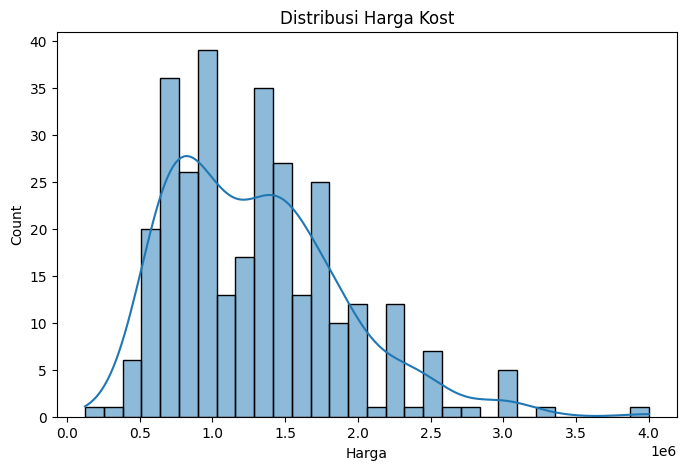

In [15]:
plt.figure(figsize=(8,5))


sns.histplot(
    df["harga"],
    bins=30,
    kde=True
)


plt.title(
    "Distribusi Harga Kost"
)


plt.xlabel(
    "Harga"
)


plt.show()

STEP 12 — Boxplot Harga

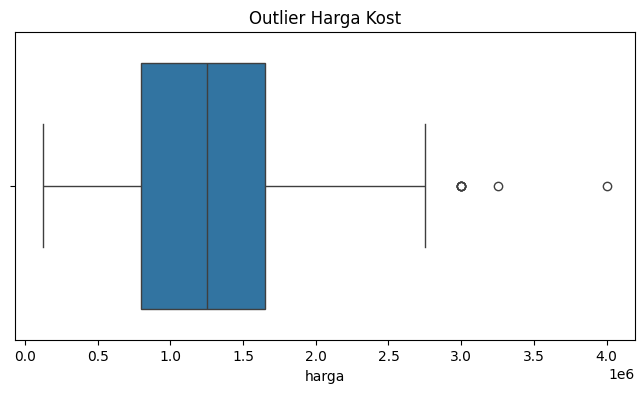

In [16]:
plt.figure(figsize=(8,4))

sns.boxplot(
    x=df["harga"]
)


plt.title(
    "Outlier Harga Kost"
)

plt.show()

STEP 13 — Analisis Jenis Kost

In [17]:
df["jenis"].value_counts()

jenis
Putri     123
Campur     66
Putra      51
putri      39
putra      19
campur     13
Name: count, dtype: int64

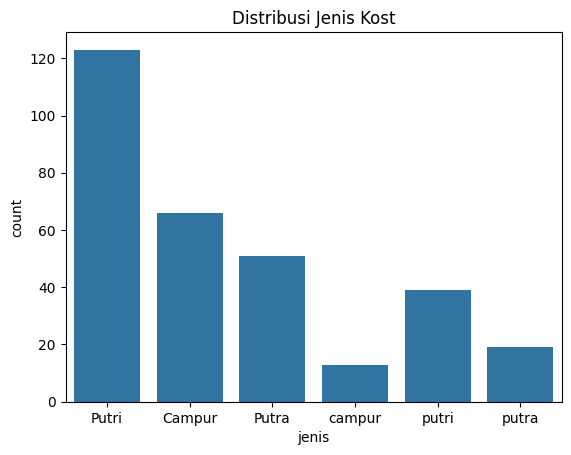

In [18]:
sns.countplot(
data=df,
x="jenis"
)

plt.title(
"Distribusi Jenis Kost"
)

plt.show()

STEP 14 — Analisis Lokasi

In [19]:
df["lokasi"].value_counts().head(10)

lokasi
Sukolilo                    91
Wonokromo                   59
Gubeng                      48
Wonocolo                    24
Rungkut                      9
Tenggilis Mejoyo             9
Menur Pumpungan Surabaya     7
Semolowaru Surabaya          6
Kutisari Surabaya            5
Pacarkembang Surabaya        4
Name: count, dtype: int64

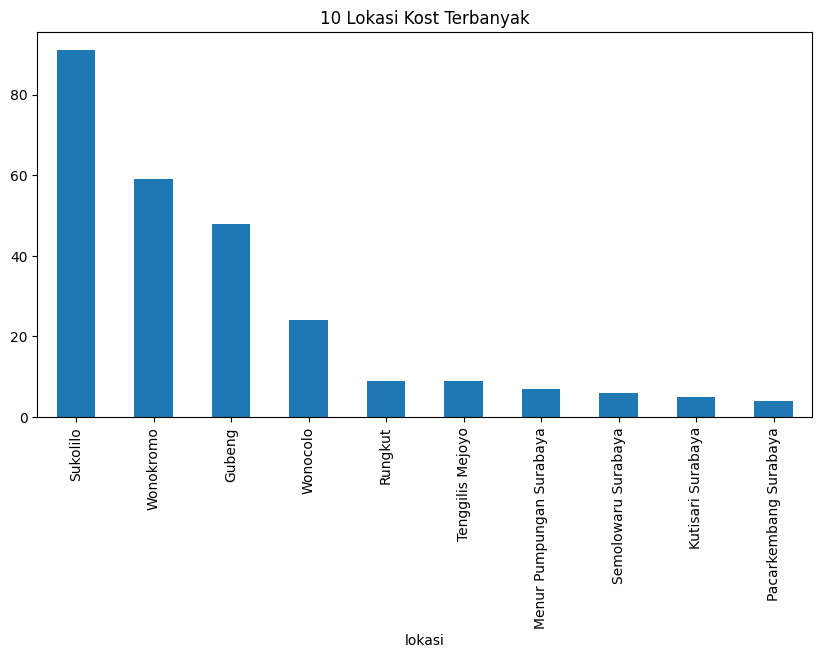

In [20]:
plt.figure(figsize=(10,5))


df["lokasi"].value_counts().head(10).plot(
kind="bar"
)


plt.title(
"10 Lokasi Kost Terbanyak"
)


plt.show()

STEP 15 — Analisis Fasilitas

In [21]:
fasilitas=[
"ac",
"wifi",
"kmandi_dalam",
"lemari",
"meja_belajar",
"kasur",
"tv",
"pmotor",
"pmobil"
]

In [22]:
df[fasilitas].sum().sort_values(
ascending=False
)

kasur           69.0
pmotor          66.0
lemari          64.0
wifi            62.0
meja_belajar    53.0
ac              44.0
kmandi_dalam    37.0
pmobil          32.0
tv              12.0
dtype: float64

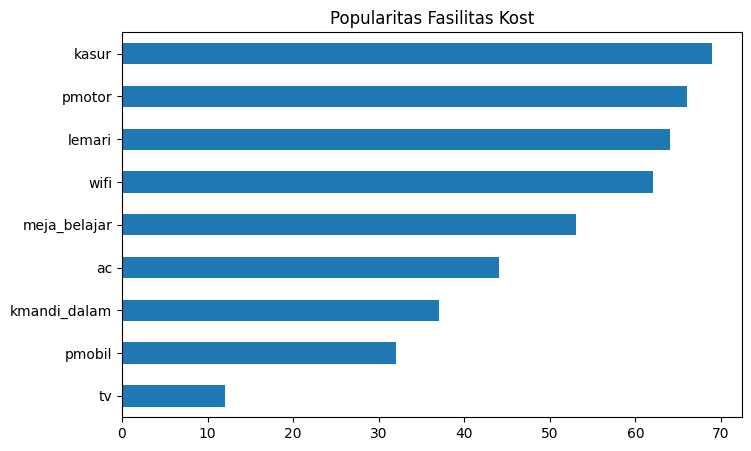

In [23]:
df[fasilitas].sum().sort_values().plot(
kind="barh",
figsize=(8,5)
)

plt.title(
"Popularitas Fasilitas Kost"
)

plt.show()

STEP 16 — Korelasi Variabel Numerik

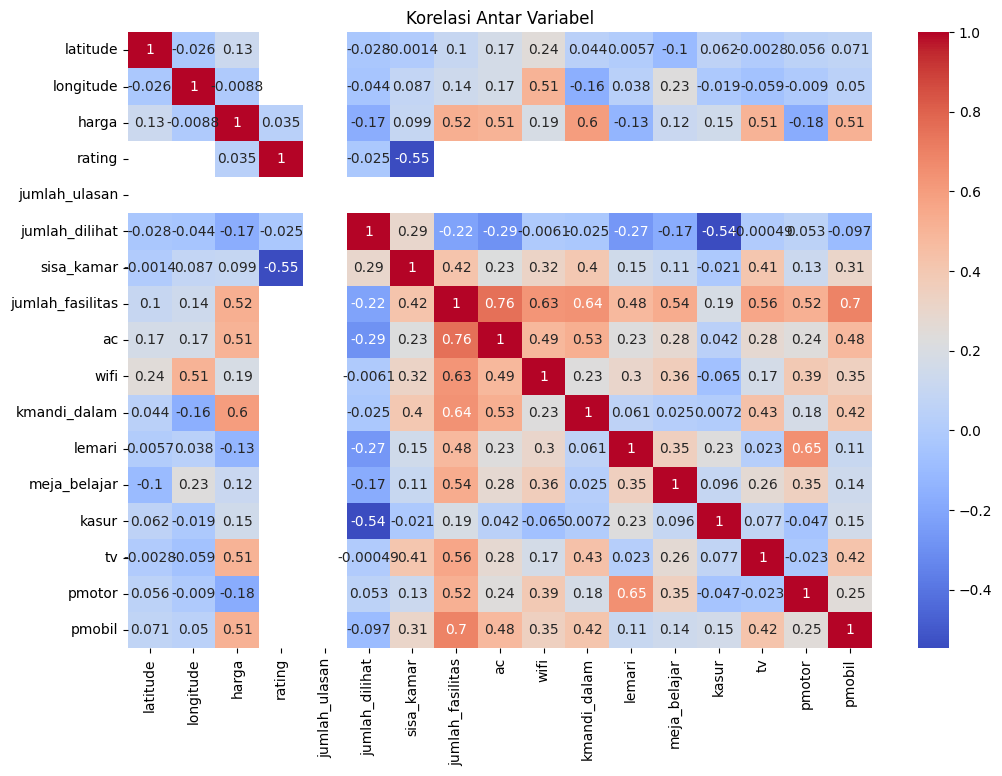

In [24]:
plt.figure(figsize=(12,8))


sns.heatmap(
    df.select_dtypes(
        include=np.number
    ).corr(),

    annot=True,
    cmap="coolwarm"
)


plt.title(
"Korelasi Antar Variabel"
)

plt.show()

STEP 17 — Analisis Harga Berdasarkan Jenis

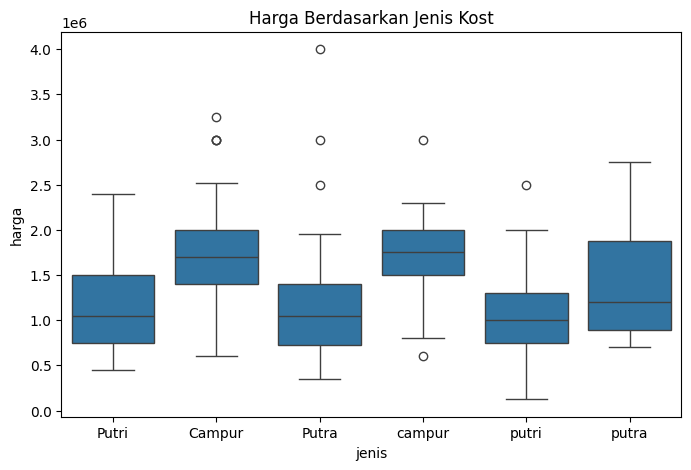

In [25]:
plt.figure(figsize=(8,5))


sns.boxplot(
data=df,
x="jenis",
y="harga"
)


plt.title(
"Harga Berdasarkan Jenis Kost"
)


plt.show()

STEP 18 — Simpan Ringkasan Dataset

In [26]:
summary = pd.DataFrame({

"Jumlah Data":[len(df)],

"Jumlah Fitur":[df.shape[1]],

"Missing Value":[df.isnull().sum().sum()],

"Duplicate":[df.duplicated().sum()]

})


summary

,Jumlah Data,Jumlah Fitur,Missing Value,Duplicate
0,311,21,3606,0


Revisi kategori kos

In [27]:
df["jenis"].value_counts()

jenis
Putri     123
Campur     66
Putra      51
putri      39
putra      19
campur     13
Name: count, dtype: int64

Buat fungsi normalisasi

In [28]:
def normalisasi_jenis(x):

    if pd.isna(x):
        return "tidak_diketahui"

    x = str(x).lower().strip()


    if "putri" in x:
        return "putri"

    elif "putra" in x:
        return "putra"

    elif "campur" in x:
        return "campur"

    else:
        return "lainnya"

Terapkan ke dataset

In [29]:
df["jenis"] = df["jenis"].apply(normalisasi_jenis)

Cek hasil perubahan

In [30]:
df["jenis"].value_counts()

jenis
putri     162
campur     79
putra      70
Name: count, dtype: int64

Buat ulang grafik

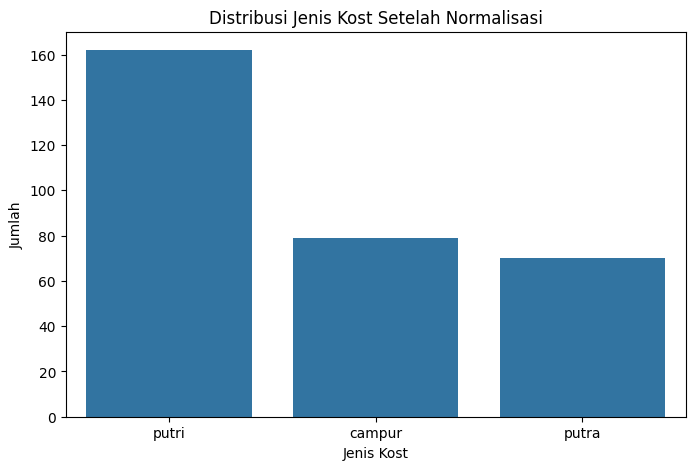

In [31]:
plt.figure(figsize=(8,5))


sns.countplot(
    data=df,
    x="jenis"
)


plt.title(
    "Distribusi Jenis Kost Setelah Normalisasi"
)


plt.xlabel(
    "Jenis Kost"
)


plt.ylabel(
    "Jumlah"
)


plt.show()

Simpan dataset hasil cleaning

In [32]:
df.to_csv(
    "kozy_dataset_clean.csv",
    index=False
)